In [1]:
# Cell 1 — imports and load
import pandas as pd
import numpy as np

# If uploading manually in Colab:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Cell 2 — pick the numeric columns worth summarizing
cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']

summary = pd.DataFrame(index=cols)
summary['count']  = df[cols].count()
summary['mean']   = df[cols].mean().round(2)
summary['median'] = df[cols].median().round(2)
summary['mode']   = df[cols].mode().iloc[0]
summary['std']    = df[cols].std().round(2)
summary['min']    = df[cols].min()
summary['p25']    = df[cols].quantile(0.25).round(2)
summary['p75']    = df[cols].quantile(0.75).round(2)
summary['IQR']    = (summary['p75'] - summary['p25']).round(2)
summary['max']    = df[cols].max()
summary['skew']   = df[cols].skew().round(2)

summary

,count,mean,median,mode,std,min,p25,p75,IQR,max,skew
Age,714,29.70,28.00,24.00,14.53,0.42,20.12,38.0,17.88,80.0000,0.39
Fare,891,32.20,14.45,8.05,49.69,0.00,7.91,31.0,23.09,512.3292,4.79
SibSp,891,0.52,0.00,0.00,1.10,0.00,0.00,1.0,1.00,8.0000,3.70
Parch,891,0.38,0.00,0.00,0.81,0.00,0.00,0.0,0.00,6.0000,2.75
Pclass,891,2.31,3.00,3.00,0.84,1.00,2.00,3.0,1.00,3.0000,-0.63


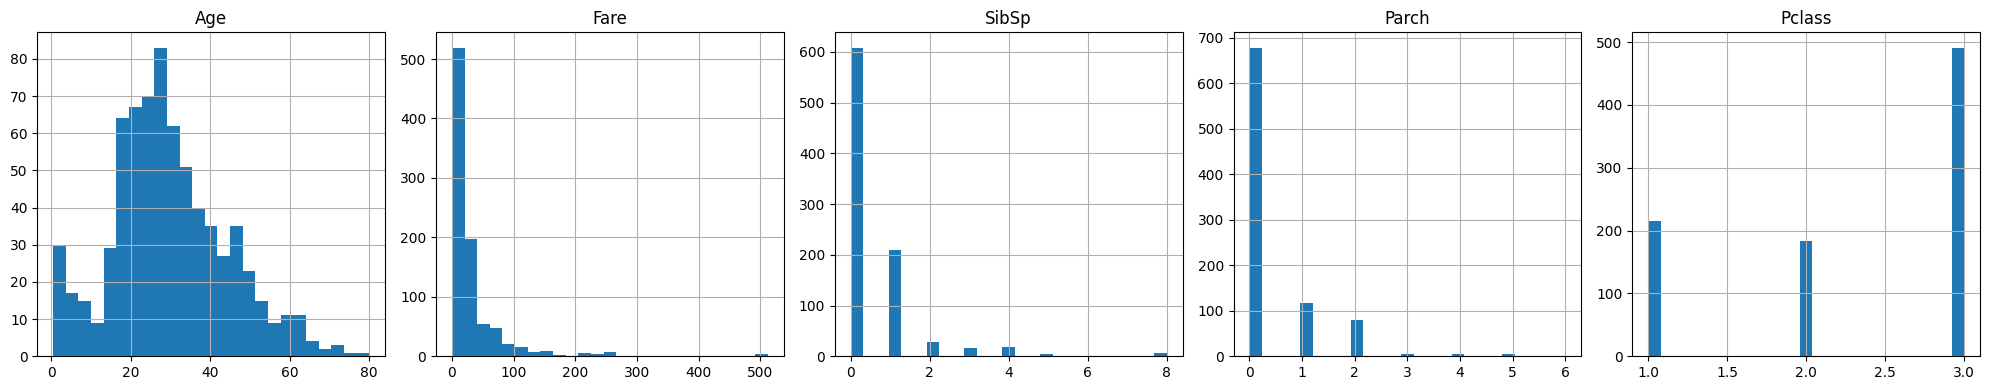

In [3]:
# Cell 3 — quick visual check of skew (optional but useful)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(cols), figsize=(20, 4))
for ax, col in zip(axes, cols):
    df[col].dropna().hist(ax=ax, bins=25)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [4]:
# Cell 4 — export the table
summary.to_csv('titanic_summary_stats.csv')